# Boosting
## Mushroom Dataset

#### Final Project: DSC 345/445
#### Victoria Burke and Rebecca Henzig


Boosting allows us to employ the advantages of decision trees (a good choice for our categorical data) to create accurate ensemble models that build upon each other to reduce prediction error, while also reducing the negative impact of overfitting associated with standard decision trees. Because boosting sequentially re-weights learners in each iteration of training based on either misclassified points (AdaBoost) or optimizing a loss function (gradient boosting/XGBoost), it allows us to penalize the misclassification of poisonous mushrooms as edible more strongly than vice versa using model hyperparameters. This makes precise tuning easier if the model struggles with recall/sensitivity at first. Boosting is therefore a useful choice of model for our specific classification problem.

In this notebook, we will try both AdaBoost and XGBoost to see which performs better.

### Data setup procedure

note: since this, like the neural networks, is a more complex model, I increased the test size to 30% to ensure high performance on a larger subset of unseen validation data. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('../data/cleaned_mushrooms.csv')

# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 123, stratify = y
)

# One-hot encoding
cat_cols = X.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

onehot_feature_names = preprocessor.get_feature_names_out()

Re-encode class labels as 0 and 1: "Poisonous" serves as the positive class. We need to tune our model to maximize recall; our goal is to correctly identify as many positive samples as possible (to avoid consuming deadly mushrooms, obviously).

In [2]:
labels = {'e': 0, 'p': 1}
y_train = y_train.map(labels)
y_test  = y_test.map(labels)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [3]:
randstate = 528491

### AdaBoost

In the first iteration of AdaBoost, we use the default number of estimators (50).

In [8]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=50, random_state=randstate)
ada.fit(X_train, y_train)
preds = ada.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



This model already works perfectly to classify the data, including 100% recall. We can try to make the model simpler by reducing the number of estimators/learners. 

In [11]:
ada = AdaBoostClassifier(n_estimators=25, random_state=randstate)
ada.fit(X_train, y_train)
preds = ada.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1263
           1       0.98      1.00      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



Halving the number of estimators to 25 reduced the metrics the slightest amount, but it is still perfect recall for class 1 (poisonous), so it is accomplishing our primary goal. 

In [15]:
ada = AdaBoostClassifier(n_estimators=35, random_state=randstate)
ada.fit(X_train, y_train)
preds = ada.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1263
           1       0.99      1.00      0.99      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



35 learners results in nearly perfect metrics. There is still one/a couple of the edible mushrooms being misclassified as poisonous. This would be a useful model in practice, but if we really wanted to eat that one borderline edible mushroom, we can increase the number of learners again slightly.

In [20]:
ada = AdaBoostClassifier(n_estimators=37, random_state=randstate)
ada.fit(X_train, y_train)
preds = ada.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



37 learners is the magic number to get perfect performance on the validation set. 

#### Feature importance (AdaBoost)

This is conveniently directly available as an attribute in the AdaBoost object, so we can make a barplot of which features contribute most strongly to the prediction.

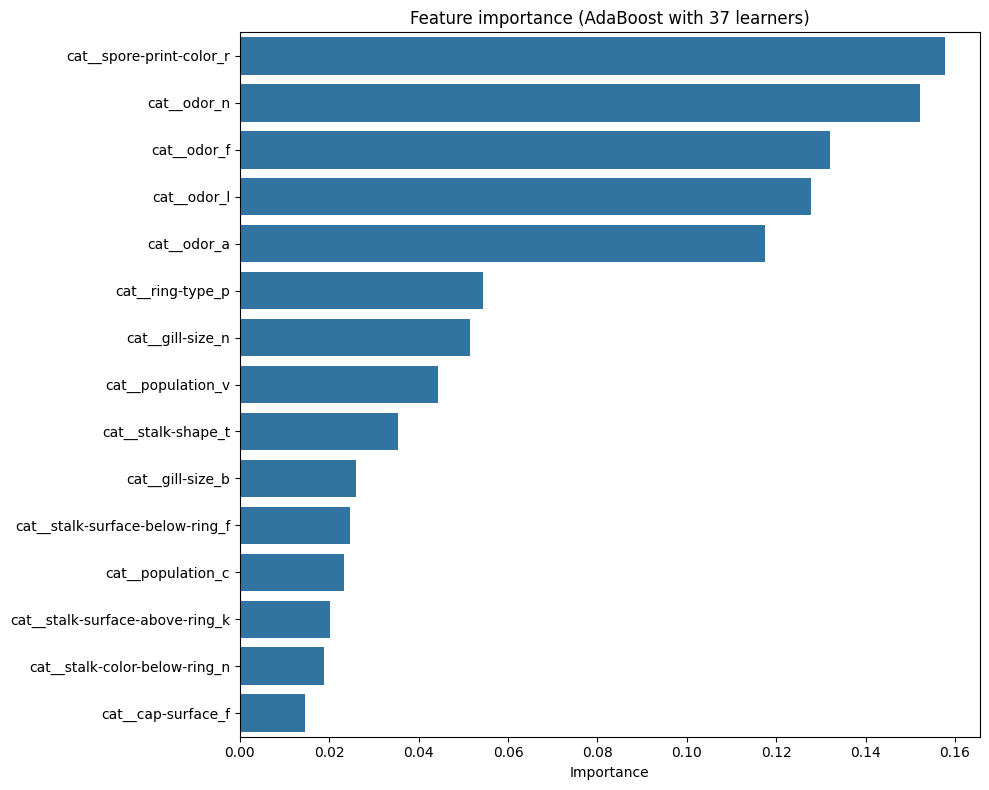

In [33]:
feat = pd.Series(ada.feature_importances_, index=onehot_feature_names)
top = feat.nlargest(15).sort_values()
top= top.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top.values, y=top.index, ax=ax)

ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.set_title("Feature importance (AdaBoost final model (37 learners)")
plt.tight_layout()
plt.show()

The most important predictor in the AdaBoost model is spore print color. Four different classes of odor are the next most important features, which suggests that odor overall is really the most important predictor for classification. Ring type, gill size, and population are the next strongest contributors. 

#### out of curiosity - AdaBoost stump (1 learner)

This dataset is extremely simple. I am wondering what the prediction stats would look like if we used only 1 weak learner/decision stump, and what feature the model would stratify on in that case. let's find out!

In [34]:
ada = AdaBoostClassifier(n_estimators=1, random_state=randstate)
ada.fit(X_train, y_train)
preds = ada.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1263
           1       0.84      0.96      0.89      1175

    accuracy                           0.89      2438
   macro avg       0.90      0.89      0.89      2438
weighted avg       0.90      0.89      0.89      2438



Accuracy for a single decision stump is 89%, but recall for the positive class is 96%! This tells us that this one decision boundary can give a good indication of whether a mushroom is poisonous. I would not eat an unknown mushroom based on this prediction, but it could be a useful tool for a fungus guide or something that explains warning signals for poisonous mushrooms.

In [37]:
feat = pd.Series(ada.feature_importances_, index=onehot_feature_names)
top = feat.nlargest(1).sort_values()

print(top)

cat__odor_n    1.0
dtype: float64


This tells us that odor is the predictor that is single-handedly best able to give an indication of whether a mushroom is poisonous or not. Now we know to always smell a wild mushroom first before eating! (Is smelling a deadly mushroom dangerous? I don't know. I'm assuming not if they collected odor data for all of the poisonous mushrooms in the dataset, but making assumptions probably isn't a great idea when dealing with toxins.)

### XGBoost

This dataset is so simple that we do not really need a powerful technique like XGBoost to create a useful model, and doing so overcomplicates the classification problem. However, I am curious to try the library out since I have not done so before, so we will train an XGBoost model anyways and compare it to the AdaBoost result.

Since we established above that complex trees are not necessary to achieve optimal classification, we will set the `max_depth` parameter to 2. The log loss evaluation metric works well for binary classification so we will keep that as is.

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=37,
    max_depth=2,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=randstate,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1263
           1       1.00      0.97      0.98      1175

    accuracy                           0.98      2438
   macro avg       0.99      0.98      0.98      2438
weighted avg       0.98      0.98      0.98      2438



With the same number of weak learners as the chosen AdaBoost model, the XGBoost model does not perform perfectly like AdaBoost did. There are more parameters to tune in this model, so it may just need some adjustment. However, I noticed that in this XGBoost model, recall is not 100% whereas precision is. This shows that while it is able to classify all true edible mushrooms as edible, it is not able to classify all true poisonous mushrooms as poisonous. This is the opposite of what we want. 

With all the other models I have trained so far, it has been slightly easier to maximize recall than the other metrics, which was good luck considering the problem at hand. XGBoost shows the opposite trend. With a sensitive problem like this, it might be better to use one of the models that did not have this issue to begin with.

Now, we will try adjusting the parameters to see how we can construct an optimal XGBoost model:


In [51]:
xgb = XGBClassifier(
    n_estimators=40,
    max_depth=2,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=randstate,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1263
           1       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



Even increasing the number of learners to 40 (with a max tree depth of 2, more complex than the AdaBoost stumps) does not maximize the evaluation metrics.

Changing the learning rate enables perfect classification on the validation set with fewer weak learners than AdaBoost uses:

In [64]:
xgb_ideal = XGBClassifier(
    n_estimators=30,
    max_depth=2,
    learning_rate=0.15,
    eval_metric='logloss',
    random_state=randstate,
    n_jobs=-1,
)
xgb_ideal.fit(X_train, y_train)
preds = xgb_ideal.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



Changing the max depth of the tree to a decision stump reduces the evaluation metrics, even when the learning rate is substantially increased:

In [62]:
xgb = XGBClassifier(
    n_estimators=30,
    max_depth=1,
    learning_rate=0.50,
    eval_metric='logloss',
    random_state=randstate,
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
preds = xgb.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1263
           1       1.00      0.99      0.99      1175

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



The model named `xgb_ideal` performed best on the validation set. 

#### Feature importance - XGBoost

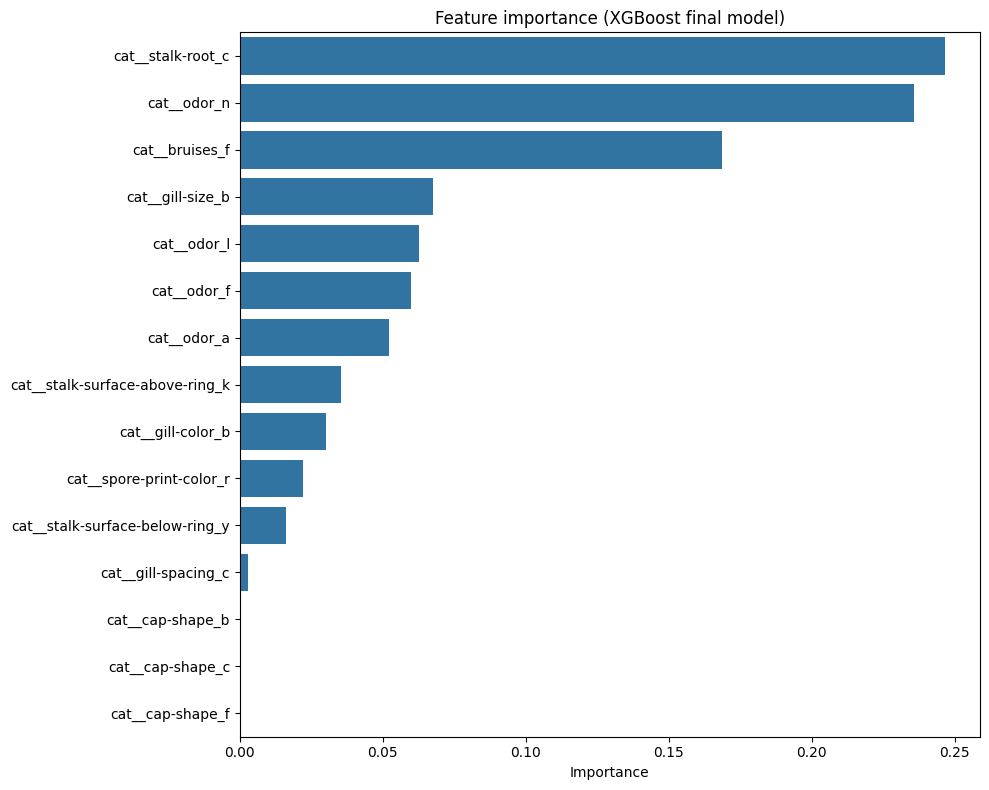

In [66]:
feat = pd.Series(xgb_ideal.feature_importances_, index=onehot_feature_names)
top = feat.nlargest(15).sort_values()
top= top.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top.values, y=top.index, ax=ax)

ax.set_xlabel("Importance")
ax.set_ylabel("")
ax.set_title("Feature importance (XGBoost final model)")
plt.tight_layout()
plt.show()

It is very interesting that XGBoost uses different features to make its prediction than all the other models I have personally developed. AdaBoost relied most on odor to make its predictions, odor was the strongest contributing feature in the neural network, and the simplest decision tree possible differentiated based on odor (indicating it is the feature that creates the best class separation in a partition). In XGBoost, the variable with highest importance is stalk root, then one class level of odor, then bruises, and then gill size. Bruises was not a major contributing feature in any other model thus far. All the other models had multiple class levels of odor as top contributors, whereas only one one-hot encoded odor variable appears in the top 4 for XGBoost.

I am curious to know why XGBoost works so differently than the other models.

### Conclusions

AdaBoost is preferable to XGBoost for this dataset. When training AdaBoost models, maximizing recall was never a problem the way it was in XGBoost. With XGBoost, recall was the hardest evaluation metric to optimize. Even though it is possible to construct an XGBoost model with 100% recall on validation data by tuning the hyperparameters, AdaBoost gave 100% recall consistently with multiple different hyperparameter values, giving us higher confidence that it can be extended to handle the high-cost task effectively on novel data. When AdaBoost made classification errors, it did so by confusing edible mushrooms for poisonous ones. XGBoost rarely did this, but did sometimes confuse poisonous mushrooms for edible ones, which we ABSOLUTELY DO NOT want. AdaBoost seems better equipped to separate out true poisonous mushrooms and ensure they are always predicted as such.

Boosting is a useful technique for this data because it is effective and explainable. It is easy to determine which features contribute most to model predictions, much more so than, for example, the neural network. This makes the boosting models (especially AdaBoost) useful for explaining model results to non-technical audiences. However, because of the simplicity of the dataset, boosting may be overcomplicating the classification problem. It could be possible, potentially, to construct a single decision tree that performs comparably. Because of AdaBoost's generalizability and ability to obtain 100% recall on validation data fairly easily, though, we would trust AdaBoost to perform this high-cost classification on a broader array of different mushroom species.